# PyTorch 기본 실습

이 노트북은 **LLM 파인튜닝 수업 전 PyTorch 핵심 개념을 빠르게 익히기 위한 입문 실습**이다.

학습 목표는 다음과 같다.

1. Tensor의 개념과 기본 연산을 이해한다.
2. `shape`, `dtype`, `device`를 다룬다.
3. `autograd`와 역전파의 기본 원리를 확인한다.
4. `nn.Module`, `Dataset`, `DataLoader`, `Optimizer`의 역할을 이해한다.
5. 간단한 학습 루프와 모델 저장/불러오기를 경험한다.
6. 이후 Hugging Face Trainer, LoRA, QLoRA 학습 코드가 어떻게 연결되는지 이해한다.

> 모든 예제는 CPU에서도 실행 가능하며, CUDA GPU가 있으면 자동으로 GPU를 사용한다.

## 0. 설치와 환경 확인

필요한 패키지가 없다면 다음 명령으로 설치한다.

`uv` 환경에서는 다음과 같이 설치할 수 있다.

```bash
uv add torch torchvision torchaudio
```

In [2]:
import torch

print("PyTorch version:", torch.__version__)
# CUDA available가 False면 GPU 학습이 불가능하므로, 드라이버/토치 빌드(cpu 전용인지)를 먼저 확인한다.
print("CUDA available:", torch.cuda.is_available())

# 코드 상단에서 device를 한 번만 정하고, 이후 모든 모델/데이터를 이 device로 보내는 것이 표준 패턴이다.
# 이렇게 해두면 CPU 노트북과 GPU 서버에서 코드 수정 없이 그대로 동작한다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 device:", device)

if torch.cuda.is_available():
    # 0번 GPU의 이름. 멀티 GPU 서버에서는 인덱스를 바꿔가며 확인한다.
    print("GPU 이름:", torch.cuda.get_device_name(0))

PyTorch version: 2.14.0+cu126
CUDA available: True
사용 device: cuda
GPU 이름: NVIDIA GeForce RTX 4060 Laptop GPU


## 1. Tensor 생성

Tensor는 PyTorch의 가장 기본적인 데이터 구조이다. NumPy의 `ndarray`와 유사하지만 GPU 연산과 자동 미분을 지원한다.

In [3]:
# 리스트로부터 Tensor 생성
# 정수 리스트를 넣으면 dtype이 int64(long)로 자동 추론된다.
x = torch.tensor([1, 2, 3, 4])
print(x)
print("shape:", x.shape)   # torch.Size([4]) -> 원소 4개짜리 1차원
print("dtype:", x.dtype)   # int64

tensor([1, 2, 3, 4])
shape: torch.Size([4])
dtype: torch.int64


In [4]:
# 실수형 Tensor
# 소수점이 하나라도 있으면 float32로 추론된다. 딥러닝 연산의 기본 dtype이 float32이다.
x_float = torch.tensor([1.0, 2.0, 3.0])
print(x_float)
print("dtype:", x_float.dtype)   # float32

tensor([1., 2., 3.])
dtype: torch.float32


In [5]:
# 0으로 채우기 - 결과 누적용 버퍼를 만들 때 자주 쓴다.
zeros = torch.zeros(2, 3)   # (행 2, 열 3) 형태
print("zeros: ", zeros)


zeros:  tensor([[0., 0., 0.],
        [0., 0., 0.]])


In [6]:
# 1로 채우기 - attention_mask처럼 "전부 유효" 마스크를 만들 때 유용하다.
ones = torch.ones(2, 3)
print("ones: ", ones)

ones:  tensor([[1., 1., 1.],
        [1., 1., 1.]])


In [7]:
# 난수 Tensor
# rand는 0~1 균등분포, randn은 평균 0/표준편차 1 정규분포이다. 가중치 초기화 실험에 사용한다.
rand = torch.rand(2, 3)
print("rand:", rand)

rand: tensor([[0.9177, 0.7182, 0.4803],
        [0.3354, 0.9089, 0.6886]])


In [8]:
rand[0]

# .item() 은 스칼라만 

tensor([0.9177, 0.7182, 0.4803])

## 2. shape, dtype, device

딥러닝 코드에서 오류가 가장 자주 발생하는 부분이 `shape`, `dtype`, `device` 불일치이다.

In [9]:
# randn: 표준정규분포 난수로 (3, 4) 크기 Tensor 생성
x = torch.randn(3, 4)

print("Tensor: ", x)
print("shape:", x.shape)    # 차원 구조. 연산 오류의 90%는 여기서 시작된다.
print("dtype:", x.dtype)    # float32 / float16 / bfloat16 등. 혼합되면 연산 에러가 난다.
print("device:", x.device)  # cpu인지 cuda:0인지. 서로 다른 device끼리는 연산할 수 없다.

Tensor:  tensor([[ 0.7500, -1.9168,  0.3601, -0.8586],
        [-1.2218, -1.1974,  0.7562, -0.9166],
        [ 0.2713, -0.2841, -0.4117,  0.8984]])
shape: torch.Size([3, 4])
dtype: torch.float32
device: cpu


In [10]:
device

device(type='cuda')

In [11]:
# dtype 변경
# 정밀도를 올리면(float64) 메모리가 2배, 내리면(float16) 절반이 된다.
# LLM에서 float16 / bfloat16을 쓰는 이유가 바로 이 메모리 절감 때문이다.
x64 = x.to(torch.float64)
print("변경 dtype:", x64.dtype)

변경 dtype: torch.float64


In [12]:
# device 이동
# .to(device)는 "복사본"을 만들어 반환한다. 원본 x는 그대로 CPU에 남아 있다.
# 따라서 반드시 반환값을 다시 변수에 받아야 한다. (x.to(device) 만 호출하면 아무 일도 안 일어난다)
x_device = x.to(device)
print("이동 후 device:", x_device.device)

이동 후 device: cuda:0


In [13]:
x_device

tensor([[ 0.7500, -1.9168,  0.3601, -0.8586],
        [-1.2218, -1.1974,  0.7562, -0.9166],
        [ 0.2713, -0.2841, -0.4117,  0.8984]], device='cuda:0')

## 3. 인덱싱과 차원 변경

LLM 입력 데이터에서도 `[batch, sequence_length]`, `[batch, sequence_length, hidden_size]` 형태를 자주 다루므로 차원 조작에 익숙해질 필요가 있다.

In [14]:
# arange: 0부터 11까지 연속된 정수 1차원 Tensor
x = torch.arange(12) # numpy arange와 동일 
print("원본:", x)


원본: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])


In [15]:
# # arange: 0부터 11까지 연속된 정수 1차원 Tensor
# x = torch.arange(1,12,2) 
# print("원본:", x)

In [16]:
x 
# 벡터 텐서로 되어있음 tensor([ 1,  3,  5,  7,  9, 11])

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [17]:
x.shape # torch.Size([6]) 값 꺼내올 때 list로 꺼내옴 ! 

torch.Size([12])

In [18]:
# 1차원 -> 2차원
# 전체 원소 개수(12)가 유지되어야 한다. 3*4 = 12 이므로 가능하다.
# -1을 쓰면 나머지 차원을 자동 계산한다. 예) x.reshape(3, -1) 도 동일한 결과
x2 = x.reshape(3, 4) 
print("reshape(3,4): \n", x2)

reshape(3,4): 
 tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])


In [19]:
# 특정 행과 열 선택
print("첫 번째 행:", x2[0])       # 0번 행 전체 -> shape (4,)
print("두 번째 열:", x2[:, 1])    # 모든 행의 1번 열 -> shape (3,)



첫 번째 행: tensor([0, 1, 2, 3])
두 번째 열: tensor([1, 5, 9])


In [20]:
# 차원 추가
# unsqueeze(0)은 맨 앞에 크기 1인 차원을 넣는다. (3,4) -> (1,3,4)
# 모델은 보통 batch 차원을 요구하므로, 샘플 1개를 추론할 때 batch 차원을 만들어주는 용도로 쓴다.
x3 = x2.unsqueeze(0)
print("unsqueeze shape:", x3.shape)

x3
# tensor([[[ 0,  1,  2,  3],
#          [ 4,  5,  6,  7],
#          [ 8,  9, 10, 11]]])


unsqueeze shape: torch.Size([1, 3, 4])


tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]]])

In [21]:
# 크기가 1인 차원 제거
# squeeze(0)은 unsqueeze의 반대. (1,3,4) -> (3,4)
# 인자 없이 squeeze()를 쓰면 크기 1인 차원을 "전부" 없애므로 의도치 않은 차원까지 사라질 수 있다.
x4 = x3.squeeze(0)
print("squeeze shape:", x4.shape) 

a = type(x4.shape)
b = list(x4.shape) # list로 캐스팅 가능 
print("타입 : ",a)
print("list로 캐스팅 :  ",b)

x4

squeeze shape: torch.Size([3, 4])
타입 :  <class 'torch.Size'>
list로 캐스팅 :   [3, 4]


tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

## 4. 기본 연산과 Broadcasting

PyTorch는 Tensor 간 산술 연산을 지원한다. 크기가 다르더라도 규칙이 맞으면 자동으로 크기를 확장하여 연산하는데 이를 Broadcasting이라고 한다.

In [22]:
a = torch.tensor([[1.0, 2.0], [3.0, 4.0]])   # shape (2, 2)
b = torch.tensor([[10.0, 20.0], [30.0, 40.0]])  # shape (2, 2)

print("덧셈: ", a + b)
# * 는 같은 위치끼리 곱하는 원소별(element-wise) 곱이다. 행렬곱이 아니다.
print("원소별 곱셈: ", a * b)


덧셈:  tensor([[11., 22.],
        [33., 44.]])
원소별 곱셈:  tensor([[ 10.,  40.],
        [ 90., 160.]])


In [23]:

# 행렬곱
# @ (= torch.matmul) 이 진짜 행렬곱이다. (n, k) @ (k, m) -> (n, m)
# 신경망의 Linear 계층이 내부에서 하는 연산이 바로 이것이다.
print("행렬곱:  ", a @ b)


행렬곱:   tensor([[ 70., 100.],
        [150., 220.]])


In [24]:

# Broadcasting
# c는 shape (2,) 이지만 (1,2) -> (2,2)로 자동 확장되어 a의 각 행에 더해진다.
# 규칙: 뒤쪽 차원부터 비교해서 크기가 같거나 한쪽이 1이면 확장 가능하다.
# 편리하지만, 의도하지 않은 shape가 조용히 확장되어 버그가 되는 경우도 많으니 항상 shape를 확인한다.
c = torch.tensor([100.0, 200.0])
print("Broadcasting 결과:\n ", a + c)

Broadcasting 결과:
  tensor([[101., 202.],
        [103., 204.]])


## 5. NumPy와 변환

전처리 과정에서는 NumPy와 PyTorch Tensor를 함께 사용하는 경우가 많다.

In [25]:
import numpy as np

np_array = np.array([1, 2, 3], dtype=np.float32)

# NumPy -> Tensor
# from_numpy는 메모리를 "공유"한다. 즉 np_array를 바꾸면 tensor_from_np도 함께 바뀐다.
# 복사본이 필요하면 torch.tensor(np_array) 를 사용한다.
tensor_from_np = torch.from_numpy(np_array)
print(tensor_from_np) # tensor([1., 2., 3.]) 이런 모양이면 다 토치 객체 


tensor([1., 2., 3.])


In [26]:

# Tensor -> NumPy
# 이 역시 CPU 메모리를 공유한다.
tensor = torch.tensor([10.0, 20.0, 30.0])
np_from_tensor = tensor.numpy()
print(np_from_tensor)


[10. 20. 30.]


In [27]:

# GPU Tensor는 바로 numpy()를 호출할 수 없다. (NumPy는 CPU 메모리만 다룬다)
# GPU 사용 시 반드시 cpu()로 이동해야 한다.
# 실전에서는 gradient 추적까지 끊기 위해 tensor.detach().cpu().numpy() 형태를 많이 쓴다.
if torch.cuda.is_available():
    gpu_tensor = tensor.to("cuda")
    print(gpu_tensor.cpu().numpy()) 

[10. 20. 30.]


## 6. Autograd와 역전파

PyTorch의 핵심 기능 중 하나이다. `requires_grad=True`로 설정한 Tensor에 대해 연산 과정을 추적하고, `backward()` 호출 시 미분값을 자동 계산한다.

In [28]:
# x에 대해 미분값을 계산하도록 설정
# requires_grad=True 를 주면 이후 x가 참여한 연산이 "계산 그래프"로 기록된다.
x = torch.tensor(2.0, requires_grad=True)
x

tensor(2., requires_grad=True)

In [29]:
# y = x^2 + 3x + 1
# 이 한 줄이 실행되는 순간 forward 계산과 동시에 그래프가 만들어진다.
y = x**2 + 3*x + 1

# .item(): 원소가 1개인 Tensor에서 파이썬 숫자만 꺼낸다. (그래프와 분리된 값)
print("y:", y.item()) # y.item() 스칼라값만 뽑아내는거임 

# 역전파 수행
# loss로부터 각 파라미터(w, b 등)의 미분값(gradient)을 계산한다.
# 실제 가중치 업데이트는 이 값을 이용해 다음 단계(optimizer.step())에서 이루어진다.
# backward()는 그래프를 거꾸로 따라가며 각 leaf tensor의 .grad에 미분값을 "누적"한다.
# 스칼라(원소 1개)에서만 인자 없이 호출할 수 있다.
y.backward() 

# dy/dx = 2x + 3 이므로 x=2에서 7.0이 나와야 한다.
# 주의: 다시 backward()를 하면 기존 grad에 더해지므로, 학습 루프에서는 매번 grad를 0으로 비워야 한다.
print("x.grad:", x.grad.item())

y: 11.0
x.grad: 7.0


## 7. Tensor만 이용한 간단한 선형회귀

다음 관계를 학습한다고 가정한다.

\[
y = 2x + 1
\]

모델은 `y_hat = wx + b` 형태이며, 경사하강법으로 `w`, `b`를 직접 갱신한다.

In [30]:
# 학습 데이터
# shape을 (4, 1)로 만든 이유: [샘플 개수, 특성 개수] 형태가 신경망 입력의 표준이기 때문이다.
x = torch.tensor([[1.0], [2.0], [3.0], [4.0]])
y = torch.tensor([[3.0], [5.0], [7.0], [9.0]])   # 정답은 y = 2x + 1


In [31]:
x #2차원 x 컬럼 1개 axios 0 

tensor([[1.],
        [2.],
        [3.],
        [4.]])

In [32]:
x.shape

torch.Size([4, 1])

In [33]:
y 

tensor([[3.],
        [5.],
        [7.],
        [9.]])

In [34]:

# 학습할 파라미터
# requires_grad=True 로 두어야 backward()가 이 값들의 gradient를 계산해준다.
w = torch.randn(1, requires_grad=True) # randn : 랜덤하게 표준 정규 분포를 따르는 값 1개 생성 
b = torch.randn(1, requires_grad=True)



In [35]:
w

tensor([0.4666], requires_grad=True)

In [36]:
b

tensor([-1.3395], requires_grad=True)

In [37]:
# 학습률(learning rate): 한 번에 파라미터를 얼마나 움직일지 결정한다.
# 너무 크면 loss가 발산하고, 너무 작으면 학습이 매우 느려진다. 가장 먼저 조정해보는 하이퍼파라미터이다.
learning_rate = 0.01 # 왜 쓰나면 경사하강법에서 한 번 업데이트할 때 가중치를 얼마나 큰 폭으로 움직일지
# 너무 크면 발산 목표지점 지나쳐버림 
# 너무 작으면 학습 느림 

for epoch in range(1000):
    # 1) 예측(forward)
    y_pred = x * w + b

    # 2) 평균제곱오차 MSE - 예측과 정답 차이를 제곱해 평균낸 값. 작을수록 좋다.
    loss = ((y_pred - y) ** 2).mean()

    # 3) 이전 gradient 초기화 -> 해야함 , 
    # PyTorch는 grad를 누적(+=)하므로, 비우지 않으면 이전 epoch의 gradient가 계속 쌓여 학습이 망가진다.
    if w.grad is not None:
        w.grad.zero_()
    if b.grad is not None:
        b.grad.zero_()

    # 4) 역전파 - loss로부터 w.grad, b.grad를 계산한다.
    loss.backward()

    # - loss 최저점 + 
    # 5) 파라미터 갱신 (경사하강법: 기울기 반대 방향으로 이동)
    # no_grad(): 이 블록의 연산은 autograd 추적에서 제외한다. -> 여기서의 w는 미분하려는 목적이 아님, 근데 계산한건 무조건 기록하려고 위에서 설정해놨음 
    # 근데 여기서는 w 를 아예 덮어씀(갱신해버림) 원래 w가 어떤 계산으로 만들어졌는지 끊겨짐. 가중치 업데이트는 미분용이 아니라 그냥 "값 수정" 임.
    # 파라미터 갱신 자체가 그래프에 기록되면 안 되고, 메모리도 낭비되기 때문이다.
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

# 정답에 가깝게 w ≈ 2, b ≈ 1 로 수렴하면 학습이 성공한 것이다.
print("학습된 w:", w.item())
print("학습된 b:", b.item())
print("최종 loss:", loss.item())

학습된 w: 2.027637481689453
학습된 b: 0.9187436103820801
최종 loss: 0.0011093552457168698


## 8. `nn.Module`과 `nn.Linear`

실제 딥러닝에서는 Tensor를 직접 갱신하지 않고 `nn.Module`을 이용해 모델을 정의한다.

In [38]:
import torch.nn as nn

# nn.Module을 상속하면 파라미터 관리(.parameters()), device 이동(.to()),
# 저장/복원(state_dict) 같은 기능을 자동으로 얻는다. Transformer 모델도 결국 이 구조이다.
class LinearRegressionModel(nn.Module):
    def __init__(self):
        # 부모 초기화를 반드시 먼저 호출해야 파라미터 등록이 정상 동작한다.
        super().__init__()
        # 입력 1개 -> 출력 1개
        # nn.Linear는 y = xW^T + b 를 수행하며, W와 b를 학습 파라미터로 자동 생성/초기화한다.
        self.linear = nn.Linear(1, 1)

    # forward는 "모델이 입력을 받아 출력을 만드는 방법"을 정의한다.
    # 호출할 때는 model.forward(x)가 아니라 model(x)로 쓴다. (hook 등 내부 처리가 함께 동작한다)
    def forward(self, x):
        return self.linear(x)

# 모델을 device로 옮긴다. 모델과 입력 데이터의 device는 반드시 같아야 한다.
model = LinearRegressionModel().to(device)
print(model)

LinearRegressionModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)


## 9. Loss와 Optimizer를 이용한 학습

일반적인 PyTorch 학습 순서는 다음과 같다.

1. `optimizer.zero_grad()`
2. 모델 예측
3. loss 계산
4. `loss.backward()`
5. `optimizer.step()`

In [ ]:
import torch.optim as optim

# 데이터를 만들 때부터 device를 지정해두면 학습 루프에서 .to(device)를 반복하지 않아도 된다.
x_train = torch.tensor([[1.0], [2.0], [3.0], [4.0]], device=device)
y_train = torch.tensor([[3.0], [5.0], [7.0], [9.0]], device=device)

In [44]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 그래프에 한글(제목, 범례 등)을 쓰면 기본 폰트로는 네모(□)로 깨져 보이므로 나눔고딕을 등록한다.
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
font_manager.fontManager.addfont(font_path)
plt.rcParams["font.family"] = font_manager.FontProperties(fname=font_path).get_name()
plt.rcParams["axes.unicode_minus"] = False  # 한글 폰트 사용 시 마이너스(-) 기호 깨짐 방지

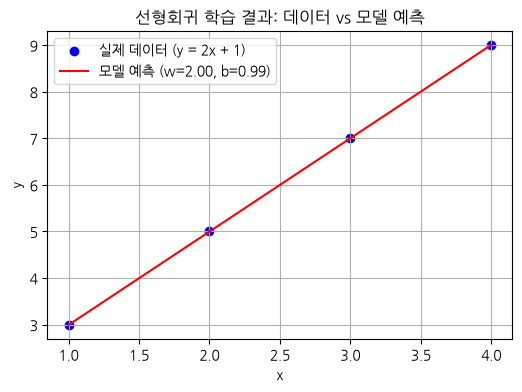

In [45]:
import matplotlib.pyplot as plt

# 시각화를 위해 GPU에 있는 Tensor를 CPU로 옮기고 numpy로 변환한다.
# matplotlib은 GPU Tensor를 직접 그릴 수 없기 때문이다.
x_plot = x_train.cpu().numpy()
y_plot = y_train.cpu().numpy()

# 학습된 모델로 x_train에 대한 예측값을 뽑아서 직선을 그릴 좌표로 사용한다.
model.eval()
with torch.no_grad():
    y_line = model(x_train).cpu().numpy()

plt.figure(figsize=(6, 4))
# 산점도: 실제 정답 데이터 (파란 점)
plt.scatter(x_plot, y_plot, color="blue", label="실제 데이터 (y = 2x + 1)")
# 직선: 모델이 학습한 w, b로 만든 예측 결과 (빨간 선)
plt.plot(
    x_plot, y_line, color="red",
    label=f"모델 예측 (w={model.linear.weight.item():.2f}, b={model.linear.bias.item():.2f})"
)
plt.xlabel("x")
plt.ylabel("y")
plt.title("선형회귀 학습 결과: 데이터 vs 모델 예측")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model = LinearRegressionModel().to(device)

# 손실함수: 회귀 문제의 기본은 MSE(평균제곱오차)이다.
criterion = nn.MSELoss() # 여기서 MSELoss() 종류 선택  
# optimizer는 model.parameters()를 넘겨받아 "어떤 파라미터를 갱신할지" 기억한다.
# LoRA에서는 여기에 전체 파라미터 대신 Adapter 파라미터만 넘기는 방식으로 학습 대상을 좁힌다.
optimizer = optim.SGD(model.parameters(), lr=0.01) # SGD 이거 선택 

for epoch in range(1000): # 1000 -> echo 선택 
    # 1. 이전 gradient 초기화 (안 하면 gradient가 누적되어 학습이 틀어진다)
    optimizer.zero_grad()

    # 2. forward - model(x)는 내부적으로 forward()를 호출한다.
    pred = model(x_train)

    # 3. loss 계산 - 인자 순서는 (예측, 정답)이다.
    loss = criterion(pred, y_train)

    # 4. backward - 각 파라미터의 .grad를 채운다.
    loss.backward()

    # 5. parameter update - .grad를 사용해 실제로 값을 갱신한다.
    # 이 5단계는 Hugging Face Trainer 내부에서도 똑같이 돌아간다.
    optimizer.step()



In [40]:
# loss

loss.item()

1.883836739580147e-05

In [41]:
model.linear.weight.item()

2.003601551055908

In [42]:
model.linear.bias

Parameter containing:
tensor([0.9894], device='cuda:0', requires_grad=True)

In [43]:
print("최종 loss:", loss.item())
print("weight:", model.linear.weight.item())   # 2에 가까워야 한다.
print("bias:", model.linear.bias.item())       # 1에 가까워야 한다.

최종 loss: 1.883836739580147e-05
weight: 2.003601551055908
bias: 0.9894111156463623


In [ ]:
# y = 2x +1
# x = 6
# y = 12 +1 => 13



## 10. Dataset과 DataLoader

데이터가 많아지면 전체 데이터를 한 번에 학습하지 않고 mini-batch 단위로 나누어 처리한다.

- `Dataset`: 데이터 1개를 어떻게 꺼낼 것인지 정의한다.
- `DataLoader`: Dataset을 batch 단위로 묶고 shuffle한다.

In [53]:
from torch.utils.data import TensorDataset, DataLoader

# (10, 1) 형태 입력과 그에 대응하는 정답을 만든다.
x = torch.arange(1, 11, dtype=torch.float32).reshape(-1, 1)
y = 2 * x + 1
y


tensor([[ 3.],
        [ 5.],
        [ 7.],
        [ 9.],
        [11.],
        [13.],
        [15.],
        [17.],
        [19.],
        [21.]])

In [ ]:

# TensorDataset: 이미 Tensor로 준비된 데이터를 (입력, 정답) 쌍으로 묶어주는 가장 간단한 Dataset이다.
# 실제 프로젝트에서는 Dataset을 상속해 __len__ / __getitem__ 을 직접 구현한다.
dataset = TensorDataset(x, y)

dataloader = DataLoader(
    dataset,
    batch_size=2,    # 한 번에 2개씩 묶어서 학습. GPU 메모리가 부족하면 가장 먼저 줄이는 값이다.
    shuffle=True     # 매 epoch마다 순서를 섞는다. 학습 데이터에는 True, 검증/테스트에는 False.
    # num_workers=4  # 데이터 로딩을 별도 프로세스로 병렬화 (대용량 데이터에서 사용)
)

# DataLoader는 반복하면 batch 단위로 (입력, 정답)을 꺼내준다.
# 데이터 10개 / batch_size 2 -> 총 5번 반복된다.
for batch_x, batch_y in dataloader:
    print("batch_x:", batch_x.squeeze().tolist()) # squeeze() -> 차원 줄어듬 
    print("batch_y:", batch_y.squeeze().tolist())
    print("---")

## 11. 간단한 분류 모델 실습

2차원 좌표를 입력받아 2개 클래스를 분류하는 간단한 예제이다.

LLM에서도 기본 구조는 동일하다.

`입력 -> 모델 -> logits -> loss -> backward -> optimizer.step()`

In [ ]:
# 재현성을 위해 seed 고정
# 난수(가중치 초기화, shuffle 등)를 고정해 실행할 때마다 같은 결과를 얻는다.
# 실험 결과를 비교하려면 반드시 필요하다.
torch.manual_seed(42)

# 가상의 2차원 데이터 생성
num_samples = 200

# 두 클래스를 (-2,-2), (2,2) 주변에 각각 흩뿌려 선형적으로 구분 가능한 데이터를 만든다.
class0 = torch.randn(num_samples // 2, 2) + torch.tensor([-2.0, -2.0])
class1 = torch.randn(num_samples // 2, 2) + torch.tensor([2.0, 2.0])

# dim=0 기준으로 이어붙이면 행(샘플)이 늘어난다 -> (200, 2)
X = torch.cat([class0, class1], dim=0)





torch.Size([200, 2]) torch.Size([200])


In [60]:
# 정답 label은 반드시 정수형(long)이어야 한다.
# CrossEntropyLoss가 label을 클래스 "인덱스"로 해석하기 때문이며, float를 주면 에러가 난다.
y = torch.cat([
    torch.zeros(num_samples // 2, dtype=torch.long),   # class0 -> 0
    torch.ones(num_samples // 2, dtype=torch.long)     # class1 -> 1
])


y.shape

torch.Size([200])

In [ ]:
torch.manual_seed(42)

# Dataset / DataLoader
# shuffle=True가 중요하다. 앞 100개가 전부 class0이라 섞지 않으면 batch가 한쪽 클래스로만 채워진다.
train_dataset = TensorDataset(X, y)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True) # 200/16 = mini_batch 갯수 => iteration 수  

print(X.shape, y.shape)   # (200, 2) (200,)

torch.Size([200, 2]) torch.Size([200])


# DNN

활성함수(비선형 함수)가 없으면, 신경망을 아무리 깊게 쌓아도 그냥 "직선 하나 긋는 것"과 수학적으로 동일하다. 활성함수가 있어야 여러 층을 쌓는 게 진짜로 "더 복잡한 패턴을 표현하는 능력"으로 이어진다.

In [ ]:
class SimpleClassifier(nn.Module):
    def __init__(self):
        super().__init__() # 생성자 필수 
        # nn.Sequential: 계층을 순서대로 통과시키는 간단한 컨테이너
        self.net = nn.Sequential(
            # nn.Linear(첫번째층, ) 그냥 시그모이드면 출력개수 1개 소프트맥스면 2개 
            nn.Linear(2, 16),    # 입력 2차원 -> 은닉 16차원 // 히든 1 
            nn.ReLU(),           # 비선형 활성화. 이게 없으면 Linear를 아무리 쌓아도 결국 선형 모델이다.
            nn.Linear(16, 2)     # 은닉 16차원 -> 클래스 2개에 대한 점수(logits) // 히든 2
        )

    def forward(self, x):
        # 마지막에 softmax를 넣지 않는다. 아래 CrossEntropyLoss가 내부에서 처리하기 때문이다.
        return self.net(x)

model = SimpleClassifier().to(device)

# CrossEntropyLoss는 다중분류에서 자주 사용하는 손실함수이다.
# 내부에서 log_softmax + NLLLoss를 함께 수행하므로 모델은 "raw logits"만 출력하면 된다.
# 여기에 softmax를 또 씌우면 학습이 잘 되지 않는다. (LLM의 언어모델링 loss도 같은 CrossEntropy이다)
criterion = nn.CrossEntropyLoss()

# Adam: 파라미터마다 학습률을 자동 조절해주는 옵티마이저. 대체로 SGD보다 빠르게 수렴한다.
# LLM 파인튜닝에서는 보통 이 계열인 AdamW를 사용한다.
optimizer = optim.Adam(model.parameters(), lr=0.01)

print(model)

SimpleClassifier(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=2, bias=True)
  )
)


In [62]:
num_epochs = 20   # 전체 데이터를 몇 바퀴 돌 것인가

for epoch in range(num_epochs):
    # 학습 모드로 전환 (Dropout / BatchNorm이 학습용으로 동작한다)
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    # 안쪽 루프 1회 = mini-batch 1개 처리 = 파라미터 1회 갱신(step)
    for batch_x, batch_y in train_loader:
        # 모델과 같은 device로 데이터를 옮긴다. 이걸 빠뜨리면 device mismatch 에러가 난다.
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        # (1) gradient 초기화
        optimizer.zero_grad()

        # (2) forward - logits 출력 (아직 확률이 아닌 raw 점수), shape: (batch, 2)
        logits = model(batch_x)
        print("logit :", logits)

        # (3) loss 계산 -> (4) backward -> (5) step. 모든 PyTorch 학습의 공통 골격이다.
        loss = criterion(logits, batch_y)
        # 역전파 , 각 노드의 미분 계수 계산 
        loss.backward()

        # weight update
        optimizer.step()

        # loss.item()은 batch 평균값이므로, batch 크기를 곱해 합계로 환산한다.
        # 마지막 batch 크기가 다를 수 있어 단순 평균보다 정확하다.
        # .item()으로 값만 꺼내야 계산 그래프가 메모리에 계속 쌓이지 않는다.

        running_loss += loss.item() * batch_x.size(0)

        # 로직값은 선형 결합 즉, 실수값
        # 가장 큰 logit의 index를 예측 클래스라고 판단한다.
        # softmax는 순서를 바꾸지 않으므로 argmax만으로 예측 클래스를 알 수 있다.
        pred = logits.argmax(dim=1)  # 점수가 가장 높은 클래스 번호를 예측값으로
        print("pred :", pred)
        correct += (pred == batch_y).sum().item() 
        total += batch_y.size(0)

    # epoch 단위 지표 집계
    epoch_loss = running_loss / total
    accuracy = correct / total

    # loss가 내려가고 accuracy가 올라가는지 반드시 확인한다. 학습이 되는지 판단하는 1차 기준이다.
    print(f"Epoch {epoch+1:02d} | loss={epoch_loss:.4f} | accuracy={accuracy:.4f}")

logit : tensor([[ 14.3877, -14.4317],
        [ -4.5291,   4.6818],
        [  8.7368,  -8.6425],
        [ 14.0975, -14.1761],
        [ -4.2193,   4.2755],
        [  5.7452,  -5.8726],
        [ -4.4751,   4.8377],
        [ -4.1899,   4.9332],
        [  7.6339,  -7.7823],
        [  4.0567,  -4.0643],
        [ -6.6257,   6.7108],
        [ -4.6387,   5.0602],
        [ 13.0606, -12.8571],
        [  7.1394,  -7.1324],
        [ -9.4213,   9.6427],
        [  7.4618,  -7.3836]], device='cuda:0', grad_fn=<AddmmBackward0>)
pred : tensor([0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0], device='cuda:0')
logit : tensor([[ -6.2707,   6.3733],
        [ -7.9798,   8.3345],
        [  8.4352,  -8.5581],
        [ -4.5923,   5.2596],
        [ -6.3665,   6.8029],
        [ 10.7728, -10.7833],
        [ -4.8328,   5.2397],
        [  8.8740,  -9.0212],
        [ 14.2937, -14.4766],
        [ -7.5661,   8.1655],
        [  8.9419,  -9.0062],
        [ -9.3625,   9.2890],
        [ -7.1730, 

## 12. `train()`과 `eval()`

`model.train()`과 `model.eval()`은 단순한 이름 변경이 아니다.

특히 다음 계층의 동작이 달라진다.

- Dropout
- BatchNorm

추론 또는 검증 시에는 일반적으로 `model.eval()`과 `torch.no_grad()`를 함께 사용한다.

In [50]:
# 추론 모드로 전환. Dropout을 끄고 BatchNorm을 학습 시 누적한 통계값으로 고정한다.
# 이걸 빠뜨리면 같은 입력에도 결과가 달라질 수 있다.
model.eval()

# 샘플 1개라도 batch 차원이 필요하므로 [[...]] 형태로 (1, 2) shape를 만든다.
sample = torch.tensor([[3.0, 2.5]], device=device)

# no_grad(): gradient 계산과 그래프 저장을 하지 않는다.
# 추론에서는 불필요한 작업이며, 메모리 사용량이 크게 줄고 속도도 빨라진다.
with torch.no_grad():
    logits = model(sample)
    # softmax로 logits를 합이 1인 확률로 변환한다. dim=1 -> 클래스 축 기준.
    # 학습에는 필요 없지만, 사람이 해석할 신뢰도를 보고 싶을 때 사용한다.
    probs = torch.softmax(logits, dim=1)
    pred = probs.argmax(dim=1)   # 확률이 가장 높은 클래스의 인덱스

print("logits:", logits)
print("probabilities:", probs)
print("prediction:", pred.item())   # (3.0, 2.5)는 class1 쪽이므로 1이 나와야 한다.

logits: tensor([[-6.1063,  6.4618]], device='cuda:0')
probabilities: tensor([[3.4812e-06, 1.0000e+00]], device='cuda:0')
prediction: 1


## 13. 모델 저장과 불러오기

PyTorch에서는 일반적으로 모델 전체보다 `state_dict`를 저장하는 방식을 권장한다.

In [51]:
MODEL_PATH = "models/simple_classifier.pt"

# 모델 파라미터 저장
# state_dict는 "계층 이름 -> 가중치 Tensor" 형태의 딕셔너리이다.
# 모델 객체 전체(torch.save(model))를 저장하면 클래스 정의 경로에 묶여 이식성이 떨어지므로 권장되지 않는다.
torch.save(model.state_dict(), MODEL_PATH)
print("저장 완료:", MODEL_PATH)

# 동일한 구조의 모델 생성
# state_dict에는 구조 정보가 없으므로, 불러오기 전에 같은 구조의 모델을 먼저 만들어야 한다.
loaded_model = SimpleClassifier().to(device)

# 저장된 파라미터 불러오기
# map_location: GPU에서 저장한 파일을 CPU에서 열 때 등 device를 맞춰주는 옵션이다. (없으면 에러가 날 수 있다)
state_dict = torch.load(MODEL_PATH, map_location=device)
# load_state_dict는 키 이름과 shape가 정확히 일치해야 성공한다. 구조를 바꿨다면 여기서 에러가 난다.
loaded_model.load_state_dict(state_dict)

# 불러온 직후에는 항상 eval()로 전환한다. (기본 상태가 train 모드이기 때문)
loaded_model.eval()

with torch.no_grad():
    output = loaded_model(sample)

# 위 셀의 logits와 같은 값이 나오면 저장/복원이 정상적으로 된 것이다.
print("불러온 모델 출력:", output)

저장 완료: models/simple_classifier.pt
불러온 모델 출력: tensor([[-6.1063,  6.4618]], device='cuda:0')


## 14. GPU 메모리와 Tensor 이동

GPU를 사용할 때 자주 확인하는 코드이다.

In [52]:
if torch.cuda.is_available():
    # memory_allocated: 실제 Tensor가 점유 중인 메모리
    print("현재 할당 메모리(MB):", torch.cuda.memory_allocated() / 1024**2)
    # memory_reserved: PyTorch가 OS로부터 미리 확보해 캐싱 중인 메모리 (항상 allocated 이상이다)
    print("예약된 메모리(MB):", torch.cuda.memory_reserved() / 1024**2)

    # 사용하지 않는 캐시 메모리 반환 요청
    # OOM(Out Of Memory)을 근본적으로 해결해주지는 않는다.
    # 실제 해법은 batch size 축소, gradient accumulation, 혼합정밀도(fp16/bf16), QLoRA 같은 양자화이다.
    torch.cuda.empty_cache()
else:
    print("CUDA GPU가 없어 CPU 환경에서 실행 중이다.")

현재 할당 메모리(MB): 16.2685546875
예약된 메모리(MB): 22.0


## 15. LLM 파인튜닝 코드와 연결해서 이해하기

지금까지 배운 PyTorch 개념은 이후 Hugging Face 파인튜닝에서 그대로 사용된다.

| PyTorch 기본 | LLM 파인튜닝에서의 의미 |
|---|---|
| Tensor | `input_ids`, `attention_mask`, `labels` |
| `device` | 모델과 데이터를 GPU로 이동 |
| `nn.Module` | Transformer 모델 자체 |
| `forward()` | 토큰 입력 → logits 출력 |
| Loss | Causal Language Modeling Loss |
| `backward()` | Transformer 파라미터의 gradient 계산 |
| Optimizer | AdamW 등으로 파라미터 갱신 |
| DataLoader | Tokenized Dataset을 batch 단위 제공 |
| `state_dict` | 모델 파라미터 저장 |
| `train()` / `eval()` | 학습 모드 / 추론 모드 |

### LoRA와 QLoRA에서 달라지는 점

기본 학습 원리는 동일하다.

```text
입력 Tensor
   ↓
Model Forward
   ↓
Loss 계산
   ↓
Backward
   ↓
Optimizer Step
```

다만 LoRA에서는 **전체 모델 파라미터가 아니라 추가된 저랭크 Adapter 파라미터를 중심으로 학습**하고, QLoRA에서는 **Base Model을 4-bit로 양자화한 상태에서 LoRA Adapter를 학습**한다.

따라서 PyTorch를 별도 심화과목 수준으로 학습할 필요는 없지만, 이 노트북의 내용 정도는 이해하고 있는 것이 Trainer API, PEFT, LoRA, QLoRA 실습에 도움이 된다.

## 16. 실습 문제

다음 문제를 직접 수정하여 실행해본다.

1. `torch.zeros(2, 3)`을 `(4, 5)` 크기로 변경한다.
2. `reshape()`를 이용해 1차원 Tensor를 2차원으로 변환한다.
3. `y = 3x^2 + 2x + 1`에서 `x=2`일 때 gradient를 PyTorch로 계산한다.
4. 선형회귀 데이터의 식을 `y = 5x - 2`로 변경하고 모델이 이를 학습하는지 확인한다.
5. 분류 모델의 hidden layer를 `16 -> 32 -> 16` 구조로 변경한다.
6. optimizer를 `Adam`에서 `SGD`로 변경하고 학습 결과를 비교한다.
7. batch size를 16, 32, 64로 변경하여 학습 속도와 결과를 비교한다.